# Dataset Exploration

This notebook is used to:

1. Verify that the dataset has been downloaded and set up correctly
2. Check the dataset split, number of images and class distribution
4. Check image specifications (dimensions, color channels)
5. Visualize samples in the dataset: normal/anomalous samples, ground-truth masks

## 1. Dataset Overview

This project uses the **cable** category from the **MVTec Anomaly Detection (MVTec AD)** dataset.

- Dataset obtained from Kaggle (https://www.kaggle.com/datasets/ipythonx/mvtec-ad?select=cable)
- More information available at the official MVTec website (https://www.mvtec.com/company/research/datasets/mvtec-ad).

## 2. Dataset Setup

### 2.1 Download the dataset

Please download the dataset from [Kaggle](https://www.kaggle.com/datasets/ipythonx/mvtec-ad?select=cable). Then, place the `cable/` folder inside the `data/` folder.

Expected folder structure:
- data/cable/train/...
- data/cable/test/...
- data/cable/ground_truth/...

### 2.2 Imports + Dataset Verification

Run the cells below to verify that the dataset has been set up correctly.

In [1]:
import os
import sys
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Some magic so that the notebook will reload external python modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [2]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.utils import DATA_DIR, TRAIN_DIR, TEST_DIR, GROUND_TRUTH_DIR, FIGURES_DIR

# Check that the directory exists and is not empty
if DATA_DIR.exists() and any(DATA_DIR.iterdir()):
    print(f"✅ Dataset set up correctly!")
    print(f"{DATA_DIR}")
else:
    print("⚠️ Dataset not found!")
    print(f"Please download the dataset from Kaggle and place it in: {DATA_DIR}")
    print("It should look like: data/cable/train/... and data/cable/test/...")

✅ Dataset set up correctly!
D:\50039-proj-group07-2026\data\cable


## 3. Dataset Information

### 3.1 Dataset Composition

Let's iterate through the directory structure to count and display the number of samples in the dataset.

In [3]:
print("Train Set:")
train_good_count = len(list((TRAIN_DIR / 'good').glob('*.png')))
print(f" - {train_good_count} normal samples\n")

print("Test Set:")
test_total = 0
anomalous_total = 0
good_total = 0
defect_categories = []

test_good_count = len(list((TEST_DIR / 'good').glob('*.png')))
print(f" - {test_good_count} normal samples")

for category_dir in sorted(TEST_DIR.iterdir()):
    if category_dir.is_dir():
        count = len(list(category_dir.glob('*.png')))
        test_total += count
        if category_dir.name != 'good':
            anomalous_total += count
            defect_categories.append(category_dir.name)
print(f" - {anomalous_total} anomalous samples ({len(defect_categories)} defect types)")

# Print number of samples in each defect category
for category_dir in sorted(TEST_DIR.iterdir()):
    if category_dir.is_dir() and category_dir.name != 'good':
        count = len(list(category_dir.glob('*.png')))
        print(f"    * {category_dir.name}: {count}")

good_total = train_good_count + test_good_count
print("\n-----------------------")
print(f"Normal Samples: {good_total}")
print(f"Anomalous Samples: {anomalous_total}")
print("-----------------------")
print(f"Train Set Size: {train_good_count}")
print(f"Test Set Size: {test_total}")
print("-----------------------")
print(f"Total Dataset Size: {train_good_count + test_total}")
print("-----------------------")

Train Set:
 - 224 normal samples

Test Set:
 - 58 normal samples
 - 92 anomalous samples (8 defect types)
    * bent_wire: 13
    * cable_swap: 12
    * combined: 11
    * cut_inner_insulation: 14
    * cut_outer_insulation: 10
    * missing_cable: 12
    * missing_wire: 10
    * poke_insulation: 10

-----------------------
Normal Samples: 282
Anomalous Samples: 92
-----------------------
Train Set Size: 224
Test Set Size: 150
-----------------------
Total Dataset Size: 374
-----------------------


### 3.2 Image Specifications

Now, let's verify some specifications of the data. Our neural network will require a consistent input size, so let's check all images in the dataset. More specifically, we are using the [Python Imaging Library (PIL)](https://pillow.readthedocs.io/en/stable/handbook/concepts.html) to check the **image dimensions** and number of **colour channels**.

- Mode `RGB` would indicate a standard 3-channel colour image.
- Mode `L` (Luminance) would indicate a 1-channel grayscale image.

In [4]:
# Check unique sizes and modes with sets
image_sizes = set()
image_modes = set()
mask_sizes = set()
mask_modes = set()

# Images: Train and test
for img_path in TRAIN_DIR.rglob('*.png'):
    with Image.open(img_path) as img:
        image_sizes.add(img.size)
        image_modes.add(img.mode)
for img_path in TEST_DIR.rglob('*.png'):
    with Image.open(img_path) as img:
        image_sizes.add(img.size)
        image_modes.add(img.mode)

# Ground truth masks for anomalous samples
for mask_path in GROUND_TRUTH_DIR.rglob('*.png'):
    with Image.open(mask_path) as mask:
        mask_sizes.add(mask.size)
        mask_modes.add(mask.mode)

print("--- Image Specifications ---")
print(f"Unique Sizes Found: {image_sizes}")
print(f"Unique Modes Found: {image_modes}")

print("\n--- Ground Truth Mask Specifications ---")
print(f"Unique Sizes Found: {mask_sizes}")
print(f"Unique Modes Found: {mask_modes}")

--- Image Specifications ---
Unique Sizes Found: {(1024, 1024)}
Unique Modes Found: {'RGB'}

--- Ground Truth Mask Specifications ---
Unique Sizes Found: {(1024, 1024)}
Unique Modes Found: {'L'}


## 4. Dataset Visualization

### 4.1 Normal and Anomalous Images

Next, let's visualize some dataset samples just to get a rough idea of what the cables and defects look like.

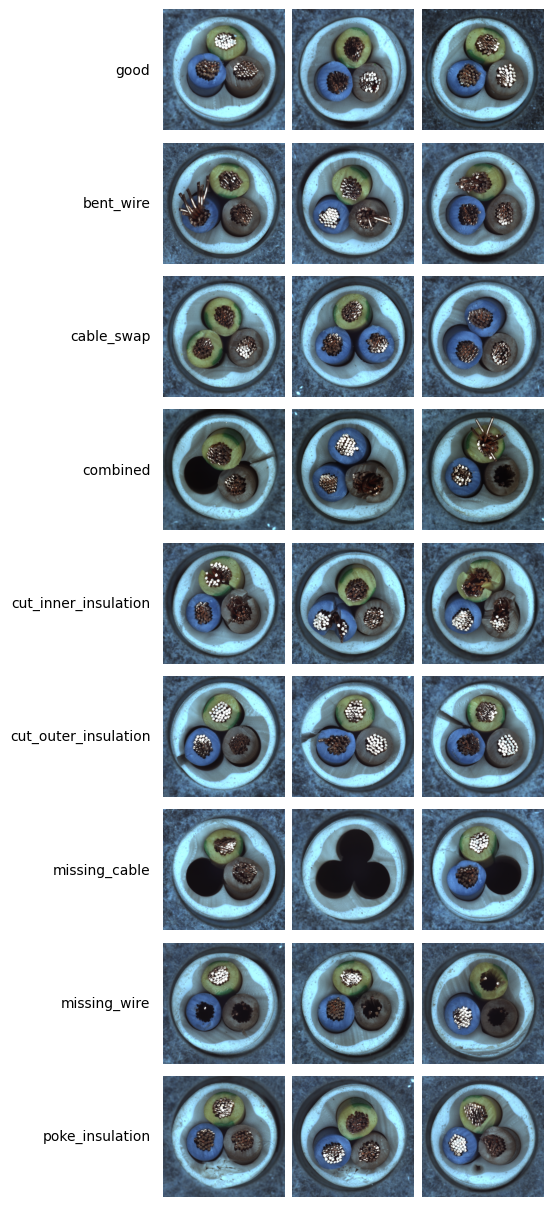

In [5]:
# Let's see a few examples from each class
categories_list = ['good'] + defect_categories
num_classes = len(categories_list)
samples_per_class = 3

plt.figure(figsize=(5.4, 12), layout='constrained')

for y, category in enumerate(categories_list):
    # Set correct path
    if category == 'good':
        img_paths = list((TRAIN_DIR / category).glob('*.png'))
    else:
        img_paths = list((TEST_DIR / category).glob('*.png'))
    
    # Select random images
    selected_paths = random.sample(img_paths, samples_per_class)
    
    for i, path in enumerate(selected_paths):
        img = Image.open(path)
        plt_idx = y * samples_per_class + i + 1
        plt.subplot(num_classes, samples_per_class, plt_idx)
        plt.imshow(img)
        plt.axis('off')
        
        # Display category name on the left of each row
        if i == 0:
            display_title = category
            plt.text(-0.1, 0.5, display_title, fontsize=10, ha='right', va='center', transform=plt.gca().transAxes)

# Save the figure for the report
# plt.savefig(FIGURES_DIR / 'Fig1_dataset_overview.png', dpi=300)
plt.show()

### 4.2 Ground-Truth Segmentation Masks

Let's also visualize some anomalous samples and their corresponding ground-truth segmentation mask.

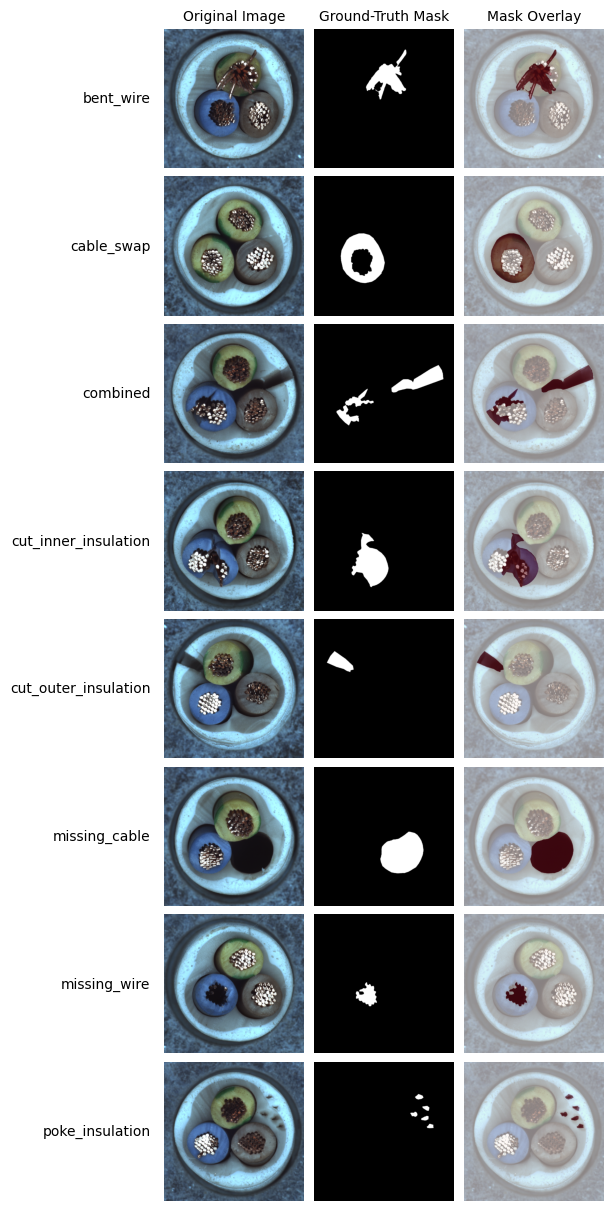

In [6]:
num_defects = len(defect_categories)
columns = 3

plt.figure(figsize=(6, 12), layout='constrained')

for y, category in enumerate(defect_categories):
    # Select random image from the category
    img_paths = list((TEST_DIR / category).glob('*.png'))
    img_path = random.choice(img_paths)
    img = Image.open(img_path)
    
    # Find corresponding mask
    mask_path = GROUND_TRUTH_DIR / category / f"{img_path.stem}_mask.png"
    mask = Image.open(mask_path)
    
    # --- Column 1: Original Image ---
    plt_idx = y * columns + 1
    ax1 = plt.subplot(num_defects, columns, plt_idx)
    ax1.imshow(img)
    ax1.axis('off')
    
    # Display category name on the left of each row
    ax1.text(-0.1, 0.5, category, fontsize=10, ha='right', va='center', transform=ax1.transAxes)
    if y == 0:
        ax1.set_title("Original Image", fontsize=10)

    # --- Column 2: Ground-Truth Mask ---
    plt_idx = y * columns + 2
    ax2 = plt.subplot(num_defects, columns, plt_idx)
    ax2.imshow(mask, cmap='gray')
    ax2.axis('off')
    if y == 0:
        ax2.set_title("Ground-Truth Mask", fontsize=10)

    # --- Column 3: Mask Overlay ---
    plt_idx = y * columns + 3
    ax3 = plt.subplot(num_defects, columns, plt_idx)
    ax3.imshow(img)
    ax3.imshow(mask, cmap='Reds', alpha=0.5) # Red translucent overlay
    ax3.axis('off')
    if y == 0:
        ax3.set_title("Mask Overlay", fontsize=10)

# Save the figure for the report
# plt.savefig(FIGURES_DIR / 'Fig2_segmask_preview.png', dpi=300)
plt.show()

### 4.3 Dataset Correction

#### 4.3.1 Error Identified
During dataset exploration, we identified a data anomaly (ironic!) within the test set. One specific image in the `bent_wire` category is **horizontally flipped** (the blue cable is on the right instead of the left). We know this is an error because the rest of the dataset have their blue cables on the left, and the `ground_truth` folder shows a defect only in the regions where the wires are bent, unlike in `cable_swap` where the entire cable of the wrong colour is highlighted. If left uncorrected, our model would probably register a higher than expected error for this image.

#### 4.3.2 Correcting the Error

We are not sure whether this error is only on the Kaggle upload or it was already present in the original, but let's go ahead and run some code to correct this error. The code below flips the image and its corresponding ground-truth mask (**run this code only once!**).

In [7]:
flipped_filename = "005.png" 

img_path = TEST_DIR / "bent_wire" / flipped_filename
mask_path = GROUND_TRUTH_DIR / "bent_wire" / f"{img_path.stem}_mask.png"

if img_path.exists() and mask_path.exists():
    img = Image.open(img_path)
    mask = Image.open(mask_path)
    
    # Horizontal flip
    fixed_img = img.transpose(Image.FLIP_LEFT_RIGHT)
    fixed_mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
    fixed_img.save(img_path)
    fixed_mask.save(mask_path)
    
    print(f"✅ Image and mask flipped!")
else:
    print(f"⚠️ Could not find '{flipped_filename}'. Please check the filename!")

✅ Image and mask flipped!


#### 4.3.3 Verification of Corrected Image

Run this code below to view the corrected image.

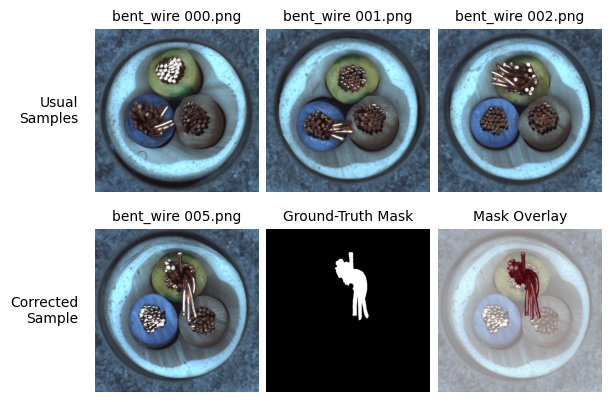

In [8]:
rows = 2
columns = 3

plt.figure(figsize=(6, 4), layout='constrained')

# === Row 1: Usual "bent_wire" Images ===
standard_filenames = ["000.png", "001.png", "002.png"]

for i, filename in enumerate(standard_filenames):
    img_path = TEST_DIR / "bent_wire" / filename
    
    plt_idx = 0 * columns + (i + 1)
    ax = plt.subplot(rows, columns, plt_idx)
    
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
    
    ax.axis('off')
    ax.set_title(f"bent_wire {filename}", fontsize=10)
    
    # Display category name on the left of the row
    if i == 0:
        ax.text(-0.1, 0.5, "Usual\nSamples", fontsize=10, ha='right', va='center', transform=ax.transAxes)

# === Row 2: Flipped & Corrected Image ===
flipped_filename = "005.png"
img_path = TEST_DIR / "bent_wire" / flipped_filename
mask_path = GROUND_TRUTH_DIR / "bent_wire" / f"{flipped_filename.split('.')[0]}_mask.png"

if img_path.exists() and mask_path.exists():
    fixed_img = Image.open(img_path)
    fixed_mask = Image.open(mask_path)
    
    # --- Column 1: Corrected Image --- 
    plt_idx = 1 * columns + 1
    ax1 = plt.subplot(rows, columns, plt_idx)
    ax1.imshow(fixed_img)
    ax1.axis('off')
    ax1.set_title(f"bent_wire {flipped_filename}", fontsize=10)
    
    # Display category name on the left of the row
    ax1.text(-0.1, 0.5, "Corrected\nSample", fontsize=10, ha='right', va='center', transform=ax1.transAxes)
    
    # --- Column 2: Ground-Truth Mask --- 
    plt_idx = 1 * columns + 2
    ax2 = plt.subplot(rows, columns, plt_idx)
    ax2.imshow(fixed_mask, cmap='gray')
    ax2.axis('off')
    ax2.set_title("Ground-Truth Mask", fontsize=10)
    
    # --- Column 3: Mask Overlay --- 
    plt_idx = 1 * columns + 3
    ax3 = plt.subplot(rows, columns, plt_idx)
    ax3.imshow(fixed_img)
    ax3.imshow(fixed_mask, cmap='Reds', alpha=0.5) # Red translucent overlay
    ax3.axis('off')
    ax3.set_title("Mask Overlay", fontsize=10)

else:
    print(f"⚠️ Could not find '{flipped_filename}' or its mask. Did you run step 4.3.2?")

plt.show()

Verify that the above image of the corrected sample and ground-truth mask are correct! Check that the blue cable is on the left and the mask highlights the bent wires correctly.

## 5. Conclusion

In this notebook, we successfully explored the cable category of the MVTec AD dataset, and confirmed some details:

1. **Dataset Distribution:** The dataset size is small, the training set consists of only normal images, and there are very few anomalous samples (only 10 to 14 per defect category). This confirms that supervised training is unfeasible and an unsupervised anomaly detection approach is required.
2. **Uniform Image Specifications:** We confirmed that all cable images are 1024x1024 RGB and all ground-truth masks are 1024x1024 grayscale, so all inputs to our neural network will be a consistent size.
3. **Dataset Quality:** The ground-truth segmentation masks provided are high-quality and accurately reflect defective regions, ensuring that model evaluations based on them will be reliable. The anomalies also seem to represent realistic manufacturing defects.
4. **Augmentation Constraints:** We observed that many factors, like environmental lighting, camera angle and cable orientation, were highly consistent throughout the dataset. This limits the amount of data augmentation we can perform.

In the next notebook, `02_baseline_autoencoder.ipynb`, we will:
* Set up the PyTorch `Dataset` and `DataLoader` to handle image resizing and normalization.
* Build and train our proposed Convolutional Autoencoder on a training set.
* Do some preliminary testing to see if our proposed model architecture can reconstruct normal cables well but fail to reconstruct anomalous images.

## References

- Paul Bergmann, Michael Fauser, David Sattlegger, and Carsten Steger, "A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection", IEEE Conference on Computer Vision and Pattern Recognition, 2019